# Gráficas de resultados — Detección de anomalías

Genera las dos figuras pendientes de la sección **Resultados** del reporte a partir
del historial real de inferencias (`response.json`, salida del endpoint
`GET /api/anomaly/inferences`):

1. **Distribución del *anomaly score*** de las inferencias almacenadas, separando
   normales de anómalas (sustituye la gráfica genérica de *clusters*).
2. **Serie temporal** de las inferencias en el tiempo, coloreadas por resultado.

Las figuras se guardan en `figures/resultados/` para incluirse con `\figuraopcional`.

In [1]:
import json
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid')

RESPONSE_PATH = pathlib.Path('response.json')
FIG_DIR       = pathlib.Path('figures/resultados')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Umbral de decisión del modelo (metadata_v1.json): is_anomaly  <=>  -score > -0.0728
# es decir, score < 0.0728. Se dibuja como frontera de decisión.
SCORE_THRESHOLD = 0.0728

In [2]:
# --- Carga del historial de inferencias ---
data  = json.loads(RESPONSE_PATH.read_text(encoding='utf-8'))
items = data['items']

df = pd.DataFrame(items)
df['createdAt'] = pd.to_datetime(df['createdAt'])
df = df.sort_values('createdAt').reset_index(drop=True)

print(f"Total de inferencias : {data['total']}")
print(f"  Anómalas           : {df['isAnomaly'].sum()}")
print(f"  Normales           : {(~df['isAnomaly']).sum()}")
df[['createdAt', 'draftId', 'score', 'isAnomaly', 'approved', 'source']]

Total de inferencias : 8
  Anómalas           : 1
  Normales           : 7


,createdAt,draftId,score,isAnomaly,approved,source
0,2026-06-28 01:36:02.398102+00:00,517a5e61-5899-48a5-ba03-a58b44f55a57,0.122702,False,True,queue
1,2026-06-28 01:37:30.999864+00:00,5e3a47df-6c1e-4ed2-9b88-921505aba743,0.122702,False,True,queue
2,2026-06-28 03:23:29.087673+00:00,870a745f-9154-4d45-9c7e-bccaf1ef385a,0.122702,False,True,queue
3,2026-06-28 03:57:52.409072+00:00,939ee566-9856-428e-a8d6-3027119efdff,0.134024,False,True,queue
4,2026-06-28 04:07:22.144630+00:00,5131d7af-05b8-4fa8-ad1f-d25c2c90da3e,0.134024,False,True,queue
5,2026-06-28 04:37:14.334709+00:00,76778821-2641-4cf8-a74b-a260d757ff0f,0.150575,False,True,queue
6,2026-06-28 05:30:33.435733+00:00,ff080f59-ad6e-4bd3-9e48-0af21e4c77f6,0.154018,False,True,queue
7,2026-06-29 03:12:14.743984+00:00,8f3a1c2e-1234-4abc-9def-0011aabbccdd,0.043285,True,False,http


## Figura 1 — Distribución del *anomaly score* por resultado

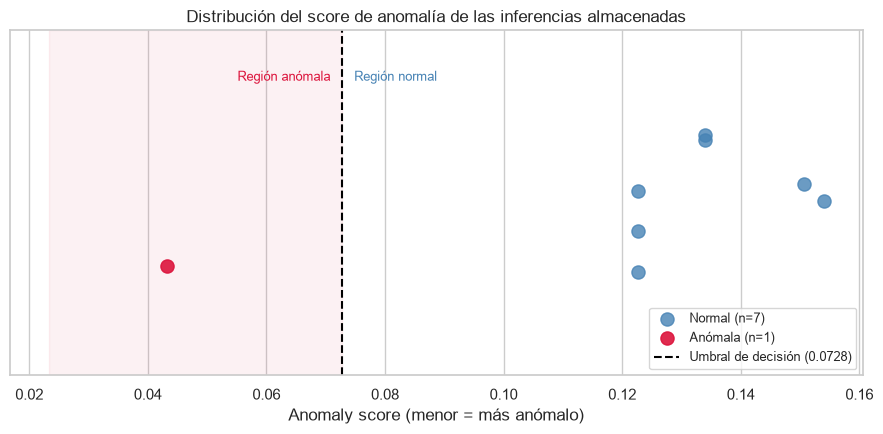

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))

normales = df[~df['isAnomaly']]['score']
anomalas = df[df['isAnomaly']]['score']

# Con pocas observaciones, un stripplot/scatter comunica mejor que un histograma.
ax.scatter(normales, np.random.uniform(-0.05, 0.05, len(normales)),
           color='steelblue', s=90, alpha=0.8, label=f'Normal (n={len(normales)})', zorder=3)
ax.scatter(anomalas, np.random.uniform(-0.05, 0.05, len(anomalas)),
           color='crimson', s=90, alpha=0.9, label=f'Anómala (n={len(anomalas)})', zorder=3)

ax.axvline(SCORE_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'Umbral de decisión ({SCORE_THRESHOLD})')
ax.axvspan(df['score'].min() - 0.02, SCORE_THRESHOLD, color='crimson', alpha=0.06)
ax.text(SCORE_THRESHOLD - 0.002, 0.085, 'Región anómala', ha='right',
        color='crimson', fontsize=9)
ax.text(SCORE_THRESHOLD + 0.002, 0.085, 'Región normal', ha='left',
        color='steelblue', fontsize=9)

ax.set_yticks([])
ax.set_ylim(-0.12, 0.12)
ax.set_xlabel('Anomaly score (menor = más anómalo)')
ax.set_title('Distribución del score de anomalía de las inferencias almacenadas')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'distribucion_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## Figura 2 — Serie temporal de inferencias almacenadas

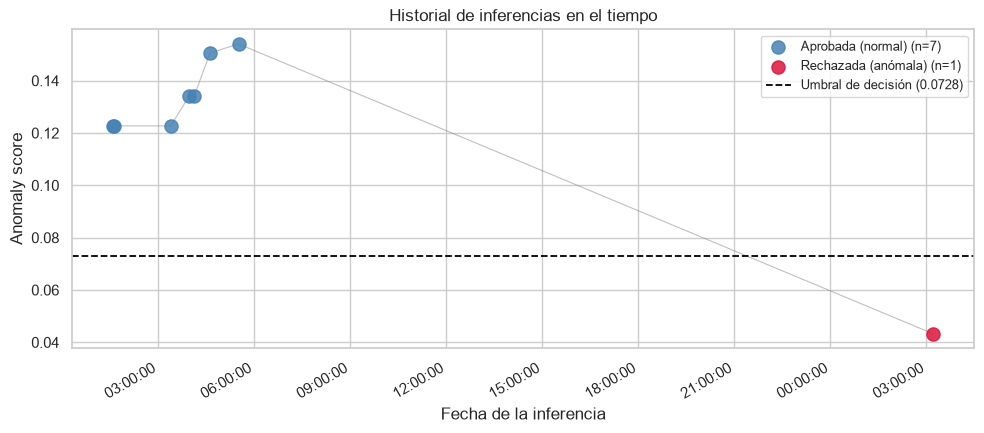

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))

for is_anom, color, label in [(False, 'steelblue', 'Aprobada (normal)'),
                              (True,  'crimson',   'Rechazada (anómala)')]:
    sub = df[df['isAnomaly'] == is_anom]
    ax.scatter(sub['createdAt'], sub['score'], color=color, s=90, alpha=0.85,
               label=f'{label} (n={len(sub)})', zorder=3)

ax.plot(df['createdAt'], df['score'], color='gray', linewidth=0.8, alpha=0.5, zorder=1)
ax.axhline(SCORE_THRESHOLD, color='black', linestyle='--', linewidth=1.3,
           label=f'Umbral de decisión ({SCORE_THRESHOLD})')

ax.set_xlabel('Fecha de la inferencia')
ax.set_ylabel('Anomaly score')
ax.set_title('Historial de inferencias en el tiempo')
ax.legend(loc='best', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(FIG_DIR / 'serie_inferencias.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
print('Figuras generadas:')
for f in sorted(FIG_DIR.glob('*.png')):
    print(' -', f)

Figuras generadas:
 - figures/resultados/distribucion_scores.png
 - figures/resultados/serie_inferencias.png
